# Questions

In [ ]:
            Part-1: Data Exploration and Pre-processing

1) load the given dataset 
2) print all the column names 
3) describe the data
4) check the null value 
5) if there are Null values, Handle these

                   Part-2: Working with Models

1) Create the target data and feature data where target data is survived
2) Split the data into Training and testing Set 
3) Create a Logistic regression model for Target and feature data 
4) Display the Confusion Matrix
5) Find the Accuracy Score 
6) Find the Precision Score 
7) Find the Recall Score 
8) Find the F1 Score 
9) Find the probability of testing data 
10) Display ROC Curve and find the AUC score

# 1) load the given dataset 

In [1]:
import pandas as pd

In [2]:
import warnings 
warnings.filterwarnings("ignore")

In [3]:
cd C:\Users\dell\OneDrive\Desktop\Finger Tips\Machine learning\Projects\Projects datafile

C:\Users\dell\OneDrive\Desktop\Finger Tips\Machine learning\Projects\Projects datafile


In [4]:
data = pd.read_csv("ML Project - Logistic Regression Titanic Survival U16955478860.txt")

# 2) print all the column names 

In [5]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

# 3) describe the data

In [6]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# 4) check the null value 

In [18]:
data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

# 5) if there are Null values, Handle these

In [10]:
data["Age"].mean()

np.float64(29.69911764705882)

In [11]:
data["Embarked"].mode()

0    S
Name: Embarked, dtype: object

In [12]:
fill = {"Age":30,"Embarked":"S"}

In [13]:
data.fillna(fill,inplace=True)

In [17]:
data.drop("Cabin", axis =1 , inplace = True)

In [22]:
data.drop(["PassengerId","Name"], axis =1, inplace = True)

# one - hot - encoding

In [28]:
Embarked = pd.get_dummies(data["Embarked"])

In [29]:
Sex  =  pd.get_dummies(data["Sex"])

In [30]:
data.drop(["Embarked","Sex"],axis = 1,inplace=True)

In [42]:
data = pd.concat([data,Sex,Embarked],axis = 1)

In [44]:
data.rename(columns={"C":"C-Embarked","Q":"Q-Embarked","S":"S-Embarked"},inplace=True)

# Label encoding

In [25]:
from sklearn.preprocessing import LabelEncoder

In [26]:
encoder = LabelEncoder()

In [27]:
data["Ticket"]=encoder.fit_transform(data["Ticket"])

# Robust Scaling

In [ ]:
#(robust scaling = Survival,sibsp,parch,fare)

In [32]:
from sklearn.preprocessing import RobustScaler

In [33]:
scaler = RobustScaler()

In [34]:
data["Survived"]=scaler.fit_transform(data[["Survived"]])

In [35]:
data["SibSp"]=scaler.fit_transform(data[["SibSp"]])

In [36]:
data["Parch"]=scaler.fit_transform(data[["Parch"]])

In [37]:
data["Fare"] = scaler.fit_transform(data[["Fare"]])

# Standard scaling

In [38]:
from sklearn.preprocessing import StandardScaler

In [39]:
scaling = StandardScaler()

In [40]:
data["Ticket"]=scaling.fit_transform(data[["Ticket"]])

In [41]:
data["Age"]= scaling.fit_transform(data[['Age']])

# 1) Create the target data and feature data where target data is survived

In [46]:
x = data.drop("Survived",axis =1)
y = data["Survived"]

# 2) Split the data into Training and testing Set 

In [47]:
from sklearn.model_selection import train_test_split

In [48]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# 3) Create a Logistic regression model for Target and feature data 

In [50]:
from sklearn.linear_model import LogisticRegression

In [51]:
model = LogisticRegression()

In [52]:
model.fit(x_train,y_train)

LogisticRegression()

# 4) Display the Confusion Matrix


In [57]:
yp = model.predict(x_test)

In [68]:
from sklearn.metrics import accuracy_score,confusion_matrix,recall_score,precision_score,classification_report,f1_score

In [60]:
c= confusion_matrix(y_test,yp)

In [59]:
import seaborn as sns

<Axes: >

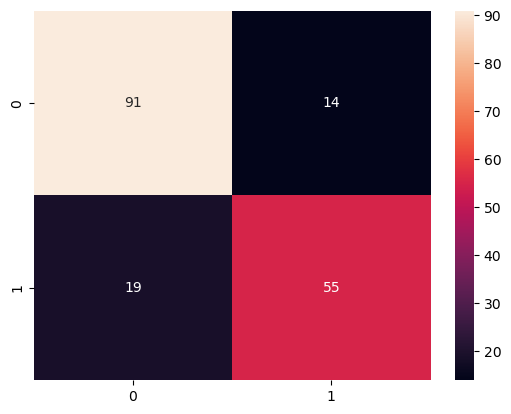

In [62]:
sns.heatmap(c,annot=True)

# 5) Find the Accuracy Score 

In [53]:
model.score(x_train,y_train)

0.8075842696629213

In [54]:
model.score(x_test,y_test)

0.8156424581005587

# 6) Find the Precision Score 


In [66]:
precision_score(y_test,yp)

0.7971014492753623

In [73]:
from sklearn.metrics import confusion_matrix,classification_report

# 7) Find the Recall Score 

In [72]:
recall_score(y_test,yp)

0.7432432432432432

# 8) Find the F1 Score 

In [73]:
f1_score(y_test,yp)

0.7692307692307693

# 9) Find the probability of testing data 

In [75]:
model.predict(x_test)

array([0., 0., 0., 1., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 1., 0.,
       1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 1.,
       0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1.,
       1., 0., 1., 0., 1., 0., 1., 1., 1., 0., 1., 1., 0., 0., 1., 0., 0.,
       0., 1., 1., 1., 1., 1., 0., 0., 1., 1., 1., 0., 0., 1., 1., 0., 0.,
       0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
       1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 1.,
       0., 0., 1., 1., 0., 0., 1., 1., 1., 1., 0., 1., 0., 0., 1., 0., 1.,
       1., 0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0.,
       1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
       1., 1., 0., 1., 0., 0., 0., 1., 1.])

# Classificaion Report

In [77]:
print(classification_report(y_test,yp))

              precision    recall  f1-score   support

         0.0       0.83      0.87      0.85       105
         1.0       0.80      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.81      0.82      0.81       179



# Random Forest

In [78]:
from sklearn.ensemble import RandomForestRegressor

In [79]:
model1 = RandomForestRegressor()

In [80]:
model1.fit(x_train,y_train)

RandomForestRegressor()

In [81]:
model1.score(x_train,y_train)

0.917493080578713

In [82]:
model1.score(x_test,y_test)

0.4160690534284285